# 🔥 Entraînement du Modèle de Prédiction des Incendies
**Projet : suivi-catastrophes-maroc**

Ce notebook couvre :
1. Chargement et exploration des données
2. Création de `severity_label` (low / medium / high)
3. Analyse de variance et corrélation
4. Préparation des features
5. Entraînement — Random Forest · Arbre de Décision · Régression Logistique
6. Évaluation et comparaison
7. Sauvegarde

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
print('✅ Librairies chargées')

✅ Librairies chargées


## 1. Chargement et Exploration des Données

In [8]:
df = pd.read_csv('../data/data_incendies.csv')
print(f'📊 Shape : {df.shape}')
print(f'📋 Colonnes : {df.columns.tolist()}')
df.head()

📊 Shape : (7971, 15)
📋 Colonnes : ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,34.4054,-6.0428,302.6,1.1,1.1,2000-12-10,1139,Terra,MODIS,53,6.03,290.2,5.4,D,0
1,33.2327,-6.8533,316.1,1.5,1.2,2000-12-12,2228,Terra,MODIS,92,6.03,280.3,32.4,N,0
2,33.2299,-6.8688,303.8,1.5,1.2,2000-12-12,2228,Terra,MODIS,57,6.03,281.3,16.7,N,0
3,34.2143,-6.0745,302.7,1.2,1.1,2000-12-14,1115,Terra,MODIS,50,6.03,292.6,4.7,D,0
4,33.6865,-7.4281,300.5,1.2,1.1,2000-12-17,1145,Terra,MODIS,0,6.03,289.5,5.4,D,2


In [9]:
df.describe()

,latitude,longitude,brightness,scan,track,acq_time,confidence,version,bright_t31,frp,type
count,7971.000000,7971.000000,7971.000000,7971.000000,7971.000000,7971.000000,7971.000000,7971.000000,7971.000000,7971.000000,7971.000000
mean,34.213486,-5.706867,328.929055,1.566767,1.198156,1298.247648,70.702798,10.101007,303.964270,58.006147,0.063982
std,1.505992,1.565771,22.105824,0.788164,0.241903,473.119906,20.541988,14.399942,10.610057,167.082216,0.353042
min,23.602800,-15.848400,300.000000,1.000000,1.000000,118.000000,0.000000,6.030000,267.700000,1.600000,0.000000
25%,33.795450,-6.083150,314.900000,1.000000,1.000000,1115.000000,58.000000,6.030000,296.000000,10.300000,0.000000
50%,34.756700,-5.595200,325.600000,1.200000,1.100000,1315.000000,71.000000,6.030000,304.300000,19.600000,0.000000
75%,35.132400,-5.066300,335.750000,1.700000,1.300000,1352.000000,86.000000,6.030000,311.400000,45.400000,0.000000
max,35.905700,-1.819100,504.600000,4.800000,2.000000,2334.000000,100.000000,61.030000,400.100000,5173.700000,3.000000


In [10]:
print('=== Valeurs nulles ===')
print(df.isnull().sum())
print(f'\nTotal : {df.isnull().sum().sum()} valeur(s) nulle(s)')

=== Valeurs nulles ===
latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_t31    0
frp           0
daynight      0
type          0
dtype: int64

Total : 0 valeur(s) nulle(s)


## 2. Création de `severity_label`

Basée sur la colonne **FRP (Fire Radiative Power, MW)** :

| Label    | Condition          |
|----------|--------------------|
| `low`    | FRP < 15           |
| `medium` | 15 ≤ FRP < 50      |
| `high`   | FRP ≥ 50           |

In [11]:
def assign_severity(frp):
    if frp < 15:
        return 'low'
    elif frp < 50:
        return 'medium'
    else:
        return 'high'

df['severity_label'] = df['frp'].apply(assign_severity)

dist = df['severity_label'].value_counts()
print('=== Distribution de severity_label ===')
print(dist)
print(f'\nProportion (%)')
print((dist / len(df) * 100).round(2))

=== Distribution de severity_label ===
severity_label
low       3190
medium    2962
high      1819
Name: count, dtype: int64

Proportion (%)
severity_label
low       40.02
medium    37.16
high      22.82
Name: count, dtype: float64


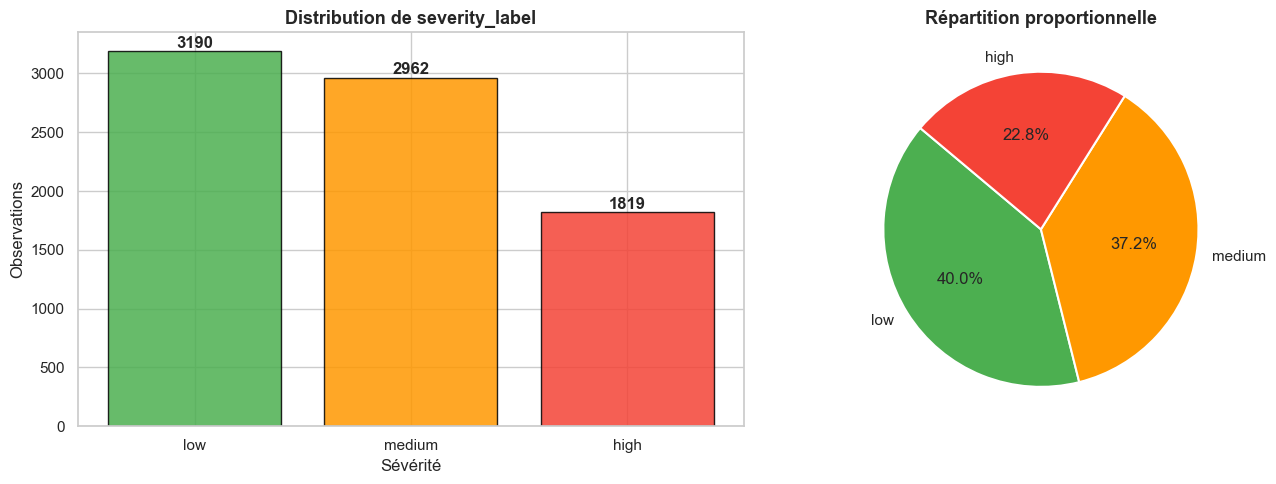

In [12]:
order  = ['low', 'medium', 'high']
colors = ['#4CAF50', '#FF9800', '#F44336']
counts = [df[df['severity_label'] == l].shape[0] for l in order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(order, counts, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribution de severity_label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sévérité'); axes[0].set_ylabel('Observations')
for i, v in enumerate(counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=order, colors=colors, autopct='%1.1f%%',
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Répartition proportionnelle', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

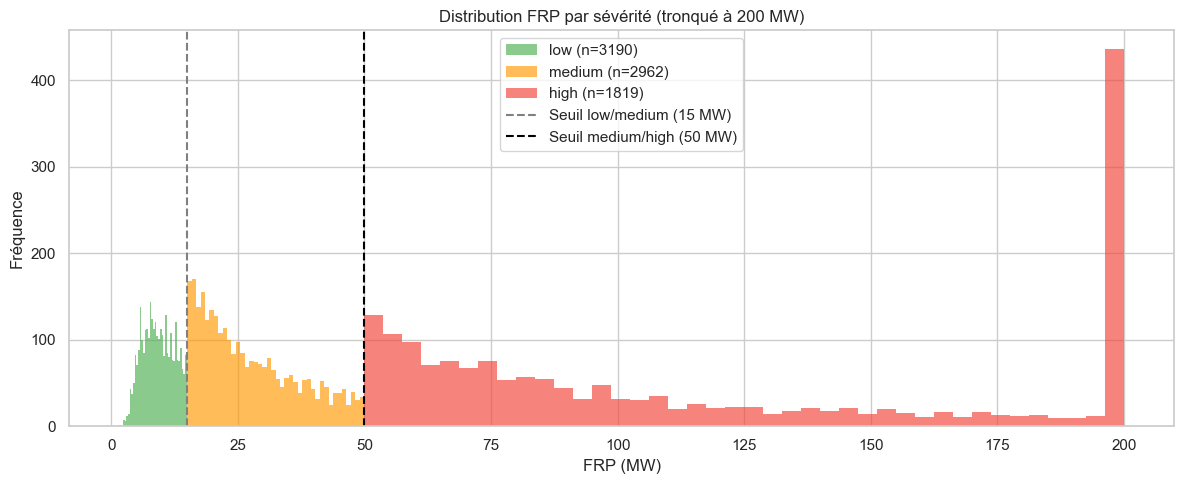

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, color in zip(order, colors):
    subset = df[df['severity_label'] == label]['frp'].clip(upper=200)
    ax.hist(subset, bins=40, alpha=0.65,
            label=f'{label} (n={len(df[df["severity_label"]==label])})',
            color=color, edgecolor='none')
ax.axvline(15, color='gray',  linestyle='--', linewidth=1.5, label='Seuil low/medium (15 MW)')
ax.axvline(50, color='black', linestyle='--', linewidth=1.5, label='Seuil medium/high (50 MW)')
ax.set_title('Distribution FRP par sévérité (tronqué à 200 MW)', fontsize=12)
ax.set_xlabel('FRP (MW)'); ax.set_ylabel('Fréquence'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Analyse de Variance et Corrélation

### 3.1 Variance des features numériques

In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
variance = df[numeric_cols].var().sort_values(ascending=False)
print('=== Variance par feature ===')
print(variance.round(4))

=== Variance par feature ===
acq_time      223842.4458
frp            27916.4669
brightness       488.6675
confidence       421.9733
version          207.3583
bright_t31       112.5733
longitude          2.4516
latitude           2.2680
scan               0.6212
type               0.1246
track              0.0585
dtype: float64


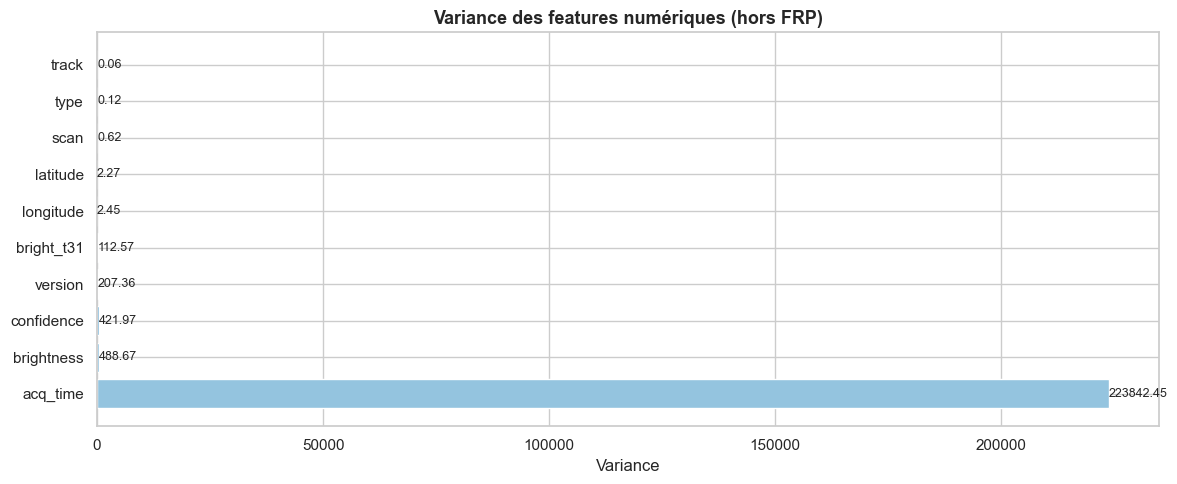

✅ Aucune feature à variance quasi-nulle détectée


In [15]:
variance_plot = variance.drop('frp', errors='ignore')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(variance_plot.index, variance_plot.values,
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(variance_plot))))
ax.set_title('Variance des features numériques (hors FRP)', fontsize=13, fontweight='bold')
ax.set_xlabel('Variance')
for bar, val in zip(bars, variance_plot.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

low_var = variance[variance < 0.01]
if not low_var.empty:
    print(f'⚠️  Features à faible variance (<0.01) : {low_var.index.tolist()}')
else:
    print('✅ Aucune feature à variance quasi-nulle détectée')

### 3.2 Matrice de Corrélation

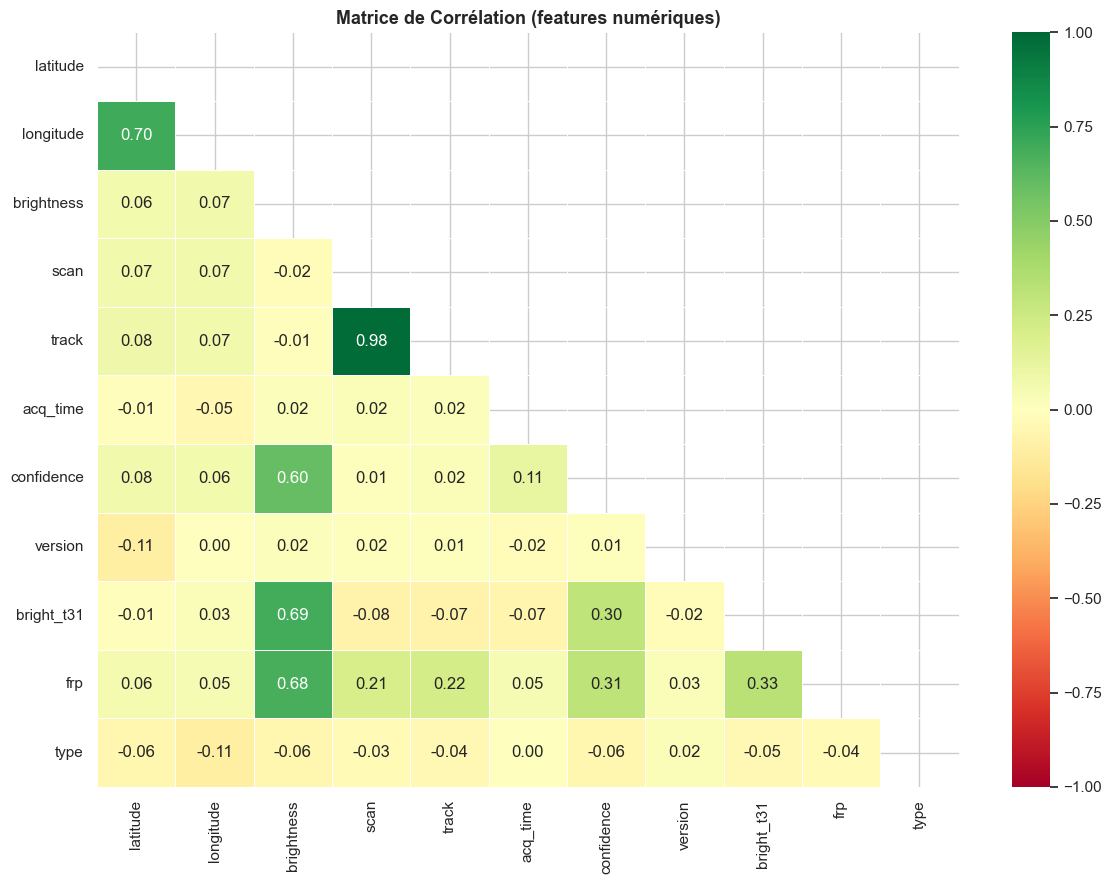

In [16]:
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de Corrélation (features numériques)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

=== Corrélation des features avec FRP ===
brightness    0.6780
bright_t31    0.3263
confidence    0.3086
track         0.2150
scan          0.2076
latitude      0.0573
acq_time      0.0529
longitude     0.0477
version       0.0271
type         -0.0357
Name: frp, dtype: float64


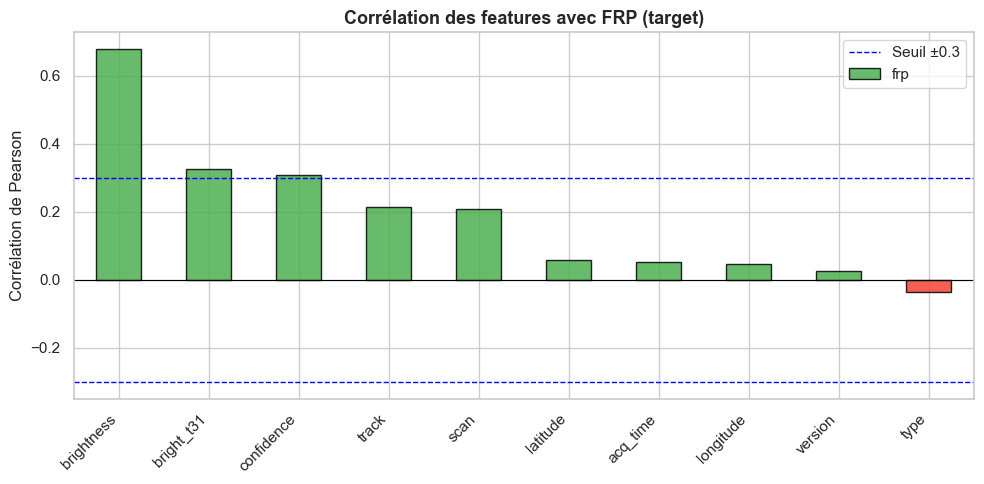

In [17]:
corr_with_frp = corr_matrix['frp'].drop('frp').sort_values(ascending=False)
print('=== Corrélation des features avec FRP ===')
print(corr_with_frp.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
corr_with_frp.plot(kind='bar', ax=ax,
                   color=['#4CAF50' if v > 0 else '#F44336' for v in corr_with_frp],
                   edgecolor='black', alpha=0.85)
ax.axhline(0,    color='black', linewidth=0.8)
ax.axhline( 0.3, color='blue', linestyle='--', linewidth=1, label='Seuil ±0.3')
ax.axhline(-0.3, color='blue', linestyle='--', linewidth=1)
ax.set_title('Corrélation des features avec FRP (target)', fontsize=13, fontweight='bold')
ax.set_ylabel('Corrélation de Pearson'); ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [18]:
print('=== Paires avec |corr| > 0.8 (multicolinéarité potentielle) ===')
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            print(f'  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]} : {val:.4f}')
            found = True
if not found:
    print('  Aucune paire avec corrélation > 0.8')

=== Paires avec |corr| > 0.8 (multicolinéarité potentielle) ===
  scan ↔ track : 0.9828


## 4. Préparation des Features

In [19]:
df_model = df.copy()

# Encodage daynight : D=1, N=0
df_model['daynight_enc'] = (df_model['daynight'] == 'D').astype(int)

# Features temporelles
df_model['acq_date'] = pd.to_datetime(df_model['acq_date'])
df_model['month']       = df_model['acq_date'].dt.month
df_model['day_of_year'] = df_model['acq_date'].dt.dayofyear

FEATURES = [
    'latitude', 'longitude',
    'brightness', 'bright_t31',
    'scan', 'track',
    'confidence',
    'daynight_enc',
    'month', 'day_of_year',
    'type'
]

X = df_model[FEATURES]

# Encodage cible
le = LabelEncoder()
le.fit(['low', 'medium', 'high'])
y_enc = le.transform(df_model['severity_label'])

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Normalisation (obligatoire pour la Régression Logistique)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Features    : {FEATURES}')
print(f'Train size  : {X_train.shape[0]}')
print(f'Test size   : {X_test.shape[0]}')
print(f'Classes     : {le.classes_}')

Features    : ['latitude', 'longitude', 'brightness', 'bright_t31', 'scan', 'track', 'confidence', 'daynight_enc', 'month', 'day_of_year', 'type']
Train size  : 6376
Test size   : 1595
Classes     : ['high' 'low' 'medium']


## 5. Entraînement des 3 Modèles

| Modèle | Type | Avantage principal |
|--------|------|--------------------|
| **Random Forest** | Ensemble | Robuste, gère multicolinéarité (scan/track) |
| **Arbre de Décision** | Arbre unique | Interprétable, visualisable |
| **Régression Logistique** | Linéaire | Baseline solide, probabilités calibrées |

In [20]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    'Arbre de Décision': DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),
    'Régression Logistique': LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    cv = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='f1_weighted')
    results[name] = {
        'model' : model,
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'cv_mean' : cv.mean(),
        'cv_std'  : cv.std()
    }
    print(f'✅ {name} — Accuracy: {results[name]["accuracy"]:.4f} | CV F1: {cv.mean():.4f} ± {cv.std():.4f}')

✅ Random Forest — Accuracy: 0.9216 | CV F1: 0.9176 ± 0.0026
✅ Arbre de Décision — Accuracy: 0.8815 | CV F1: 0.8865 ± 0.0059
✅ Régression Logistique — Accuracy: 0.9135 | CV F1: 0.9160 ± 0.0018


## 6. Évaluation et Comparaison

In [21]:
for name, res in results.items():
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'Accuracy              : {res["accuracy"]:.4f}')
    print(f'CV F1-weighted 5-fold : {res["cv_mean"]:.4f} ± {res["cv_std"]:.4f}')
    print(classification_report(y_test, res['y_pred'], target_names=le.classes_))


  Random Forest
Accuracy              : 0.9216
CV F1-weighted 5-fold : 0.9176 ± 0.0026
              precision    recall  f1-score   support

        high       0.96      0.94      0.95       364
         low       0.93      0.93      0.93       638
      medium       0.89      0.90      0.90       593

    accuracy                           0.92      1595
   macro avg       0.93      0.92      0.93      1595
weighted avg       0.92      0.92      0.92      1595


  Arbre de Décision
Accuracy              : 0.8815
CV F1-weighted 5-fold : 0.8865 ± 0.0059
              precision    recall  f1-score   support

        high       0.91      0.90      0.91       364
         low       0.90      0.91      0.91       638
      medium       0.84      0.84      0.84       593

    accuracy                           0.88      1595
   macro avg       0.88      0.88      0.88      1595
weighted avg       0.88      0.88      0.88      1595


  Régression Logistique
Accuracy              : 0.9135
CV

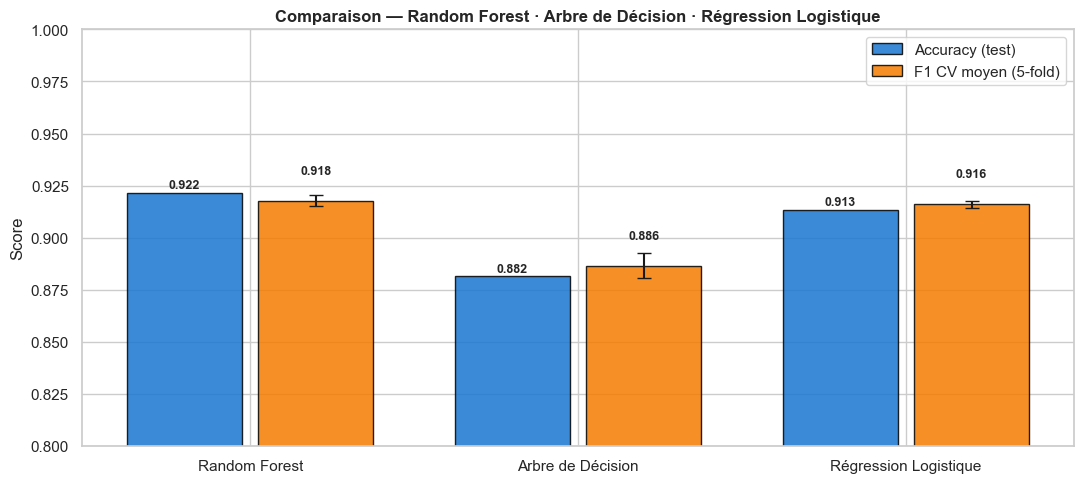

In [22]:
# Comparaison visuelle
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
cvs   = [results[n]['cv_mean']  for n in names]
stds  = [results[n]['cv_std']   for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - 0.2, accs, width=0.35, label='Accuracy (test)',
            color='#1976D2', alpha=0.85, edgecolor='black')
b2 = ax.bar(x + 0.2, cvs,  width=0.35, label='F1 CV moyen (5-fold)',
            color='#F57C00', alpha=0.85, edgecolor='black', yerr=stds, capsize=5)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.013,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0.80, 1.0)
ax.set_ylabel('Score')
ax.set_title('Comparaison — Random Forest · Arbre de Décision · Régression Logistique',
             fontsize=12, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

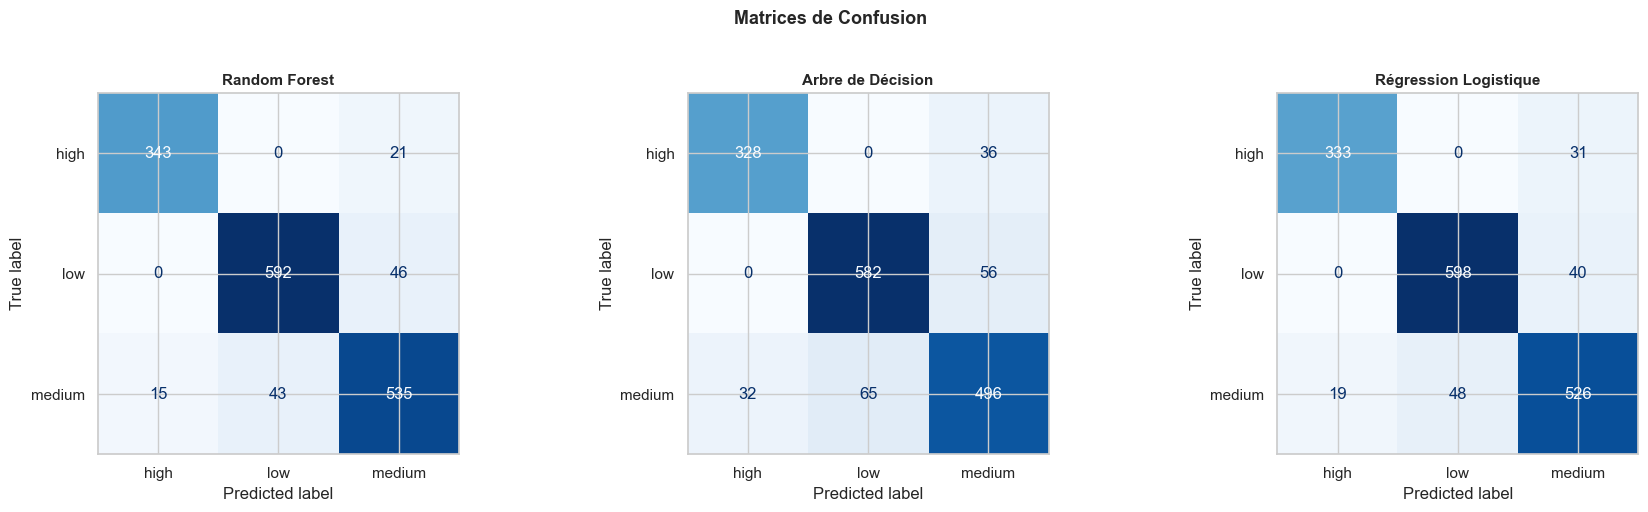

In [23]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name, fontsize=11, fontweight='bold')
plt.suptitle('Matrices de Confusion', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

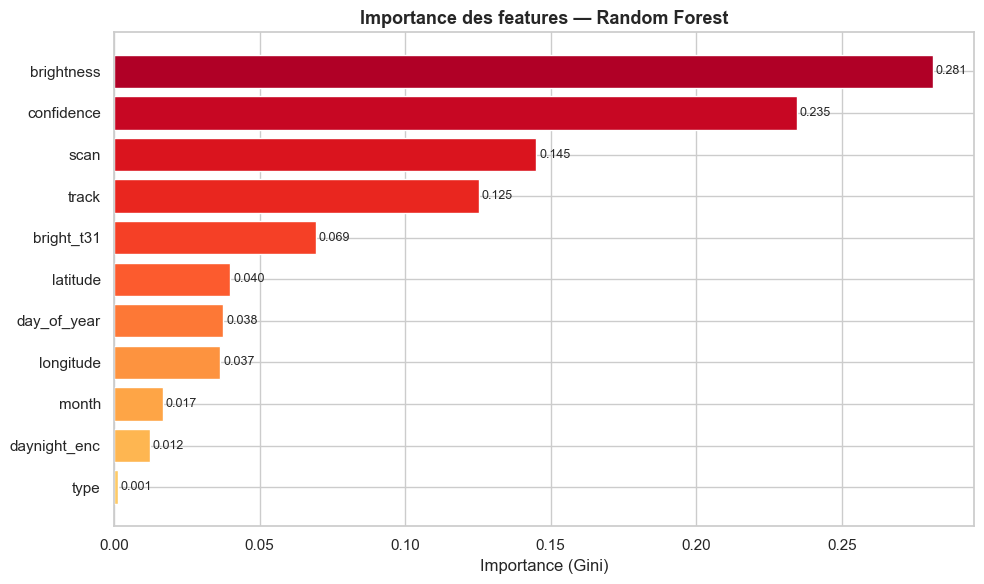

In [24]:
# Feature importance — Random Forest
feat_imp = pd.Series(
    results['Random Forest']['model'].feature_importances_, index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_imp.index, feat_imp.values,
               color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feat_imp))))
ax.set_title('Importance des features — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gini)')
for bar, val in zip(bars, feat_imp.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

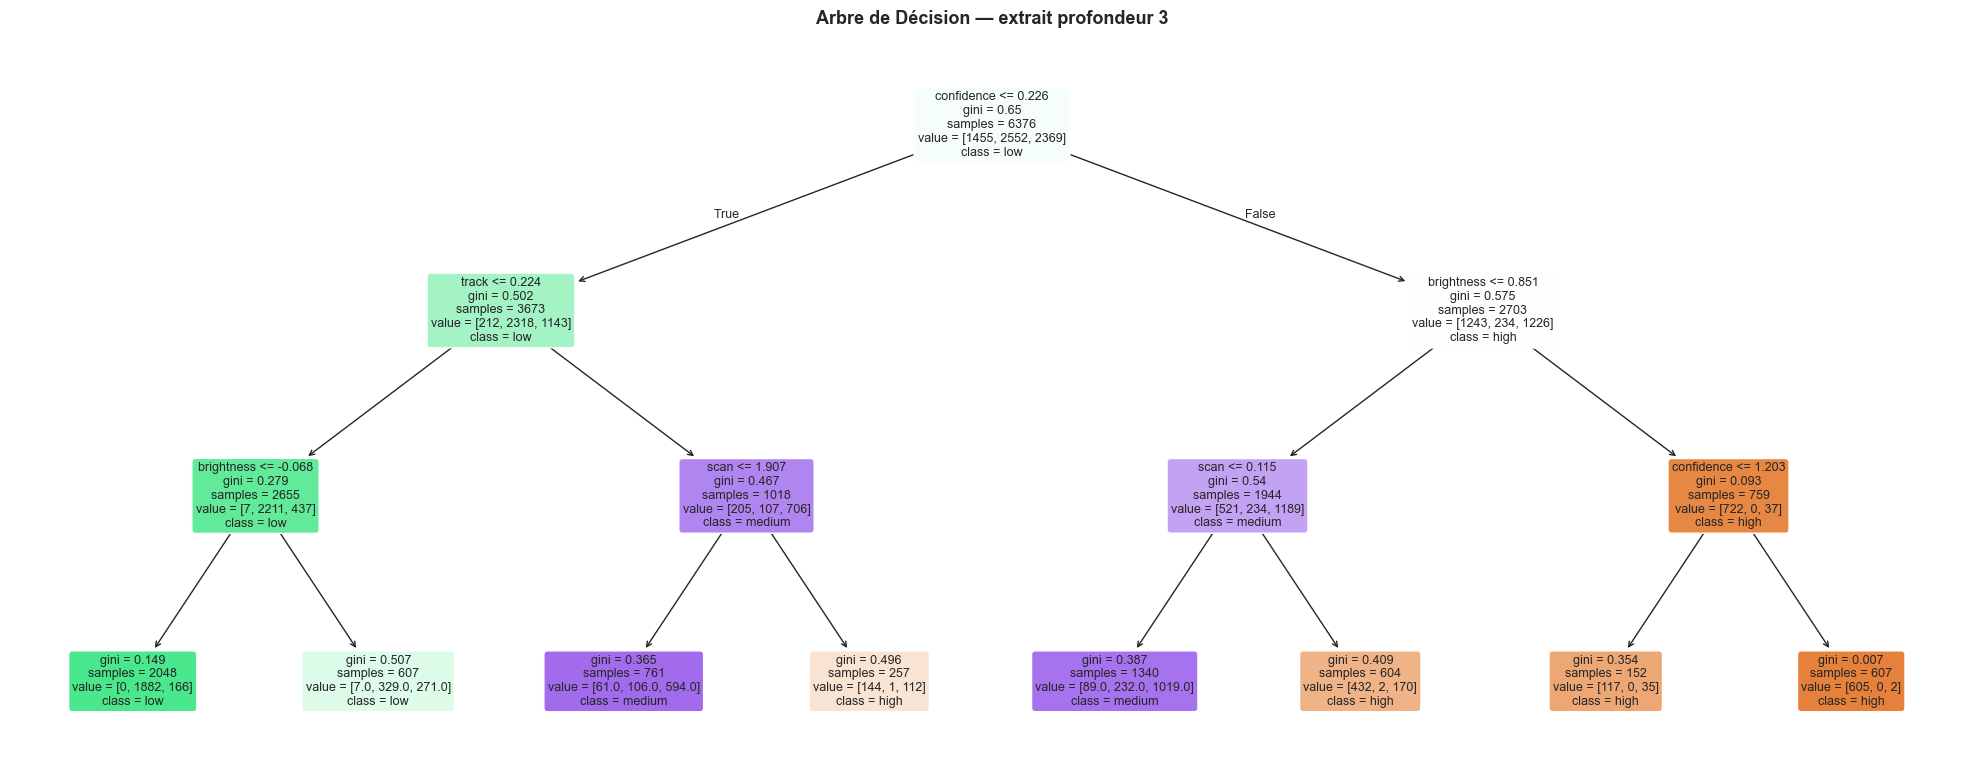

In [25]:
# Visualisation Arbre de Décision (profondeur 3 pour lisibilité)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train_sc, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_viz, feature_names=FEATURES, class_names=le.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Arbre de Décision — extrait profondeur 3', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

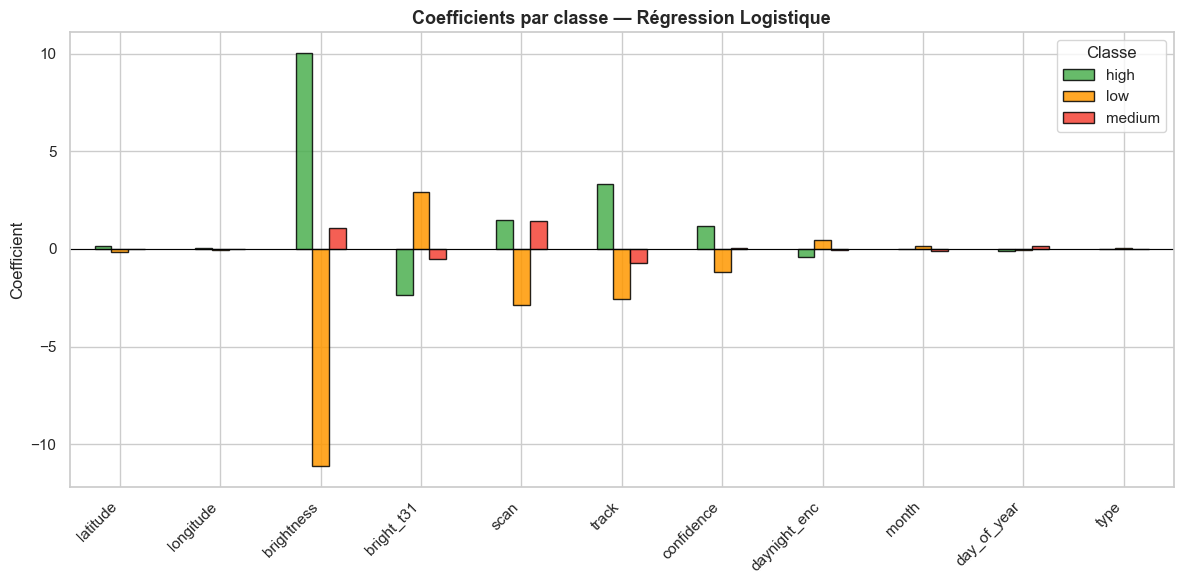

In [26]:
# Coefficients — Régression Logistique
lr = results['Régression Logistique']['model']
coef_df = pd.DataFrame(lr.coef_, columns=FEATURES, index=le.classes_).T

fig, ax = plt.subplots(figsize=(12, 6))
coef_df.plot(kind='bar', ax=ax,
             color=['#4CAF50', '#FF9800', '#F44336'],
             edgecolor='black', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Coefficients par classe — Régression Logistique', fontsize=13, fontweight='bold')
ax.set_ylabel('Coefficient'); ax.legend(title='Classe')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 7. Sauvegarde

In [27]:
import pickle, os

os.makedirs('../models', exist_ok=True)

to_save = {
    'random_forest'        : results['Random Forest']['model'],
    'decision_tree'        : results['Arbre de Décision']['model'],
    'logistic_regression'  : results['Régression Logistique']['model'],
    'scaler'               : scaler,
    'label_encoder'        : le
}

for fname, obj in to_save.items():
    path = f'../models/{fname}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'✅ Sauvegardé : {path}')

# Dataset enrichi
df_export = df.copy()
df_export['daynight_enc'] = (df_export['daynight'] == 'D').astype(int)
df_export['acq_date_dt']  = pd.to_datetime(df_export['acq_date'])
df_export['month']        = df_export['acq_date_dt'].dt.month
df_export['day_of_year']  = df_export['acq_date_dt'].dt.dayofyear
df_export.drop(columns=['acq_date_dt'], inplace=True)
df_export.to_csv('data_incendies_with_severity.csv', index=False)
print(f'\n✅ Dataset enrichi sauvegardé : data_incendies_with_severity.csv')
print(f'   Shape finale : {df_export.shape}')
print(f'   Nouvelles colonnes : severity_label, daynight_enc, month, day_of_year')

✅ Sauvegardé : ../models/random_forest.pkl
✅ Sauvegardé : ../models/decision_tree.pkl
✅ Sauvegardé : ../models/logistic_regression.pkl
✅ Sauvegardé : ../models/scaler.pkl
✅ Sauvegardé : ../models/label_encoder.pkl

✅ Dataset enrichi sauvegardé : data_incendies_with_severity.csv
   Shape finale : (7971, 19)
   Nouvelles colonnes : severity_label, daynight_enc, month, day_of_year
